# Notebook 1: scikit-learn at scale

The goal of this notebook is to give you a sense of some of the computational limitations one may encounter when training or applying ML models on large scale datasets, as well as to explore some of scikit-learn's tools to improve runtime.

__If you are taking this class for credit, you will need to turn in your completed notebook on Moodle.__

This notebook was prepared on Jupyter Lab 3.2.9 by [Chloé Azencott](http://cazencott.info), using Python 3.9.7 with `joblib 1.1.0`, `matplotlib 3.5.1`, `numpy 1.21.2`, `scipy 1.7.3`, and `sklearn 1.0.2`.

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
plt.rc('font', **{'size': 12}) # règle la taille de police globalement pour les plots (en pt)

## 1. Data setup

We will work with the [Forest Covertypes](https://scikit-learn.org/stable/datasets/real_world.html#forest-covertypes) data set.

In [7]:
from sklearn import datasets

In [8]:
forest_dataset = datasets.fetch_covtype()

In [9]:
forest_dataset

{'data': array([[2.596e+03, 5.100e+01, 3.000e+00, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.590e+03, 5.600e+01, 2.000e+00, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.804e+03, 1.390e+02, 9.000e+00, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        ...,
        [2.386e+03, 1.590e+02, 1.700e+01, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.384e+03, 1.700e+02, 1.500e+01, ..., 0.000e+00, 0.000e+00,
         0.000e+00],
        [2.383e+03, 1.650e+02, 1.300e+01, ..., 0.000e+00, 0.000e+00,
         0.000e+00]], shape=(581012, 54)),
 'target': array([5, 5, 2, ..., 3, 3, 3], shape=(581012,), dtype=int32),
 'frame': None,
 'target_names': ['Cover_Type'],
 'feature_names': ['Elevation',
  'Aspect',
  'Slope',
  'Horizontal_Distance_To_Hydrology',
  'Vertical_Distance_To_Hydrology',
  'Horizontal_Distance_To_Roadways',
  'Hillshade_9am',
  'Hillshade_Noon',
  'Hillshade_3pm',
  'Horizontal_Distance_To_Fire_Points',
  'Wilderness_Area_0',
  'Wilde

In [10]:
X = forest_dataset['data']
y = forest_dataset['target']

In [11]:
X.shape, y.shape

((581012, 54), (581012,))

In [12]:
n_samples = X.shape[0]
n_features = X.shape[1]

#### Creating subsets of varying sample sizes

The data set contains about 500k samples. Let us create subsets of the data, to explore how sample sizes affects complexity. We'll use the `train_test_split` function of sklearn to that effect.

In [13]:
from sklearn import model_selection

In [14]:
subsample_sizes = [500, 1000, 5000, 10000, 50000, 75000, 100000]
subsample_data = {} # key: number of subsamples, value:(X_subsample, y_subsample)
for ssize in subsample_sizes:
    X_tr, X_te, y_tr, y_te = model_selection.train_test_split(X, y, shuffle=True, random_state=57, stratify=y, train_size=ssize)
    subsample_data[ssize] = (X_tr, y_tr)
del X_te, y_te

# Adding the full data set to the dictionary
subsample_data[n_samples] = (X, y)
subsample_sizes.append(n_samples)

subsample_sizes = np.array(subsample_sizes)

__IMPORTANT NOTE:__ If later in the notebook cells are taking too long to run, reduce the values in `subsample_sizes`. For example, consider 
```python
subsample_sizes = [500, 1000, 5000, 10000, 50000, 75000, 100000]
```
or
```python
subsample_sizes = [500, 1000, 5000, 10000, 25000, 50000]
```

#### Size of each data set in memory

In [195]:
for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    print(f"Dataset with {ssize} samples takes {(X_current.size * X_current.itemsize):.2e} bytes of memory")

Dataset with 500 samples takes 2.16e+05 bytes of memory
Dataset with 1000 samples takes 4.32e+05 bytes of memory
Dataset with 5000 samples takes 2.16e+06 bytes of memory
Dataset with 10000 samples takes 4.32e+06 bytes of memory
Dataset with 50000 samples takes 2.16e+07 bytes of memory
Dataset with 100000 samples takes 4.32e+07 bytes of memory
Dataset with 200000 samples takes 8.64e+07 bytes of memory
Dataset with 581012 samples takes 2.51e+08 bytes of memory


Our datasets take from 216 KB to 251 MB of space in memory.

## 2. Decision trees

### 2.1 Training a decision tree: complexity w.r.t. the number of samples

The computational complexity for building a decision tree with CART is about $\mathcal{O}(p n \log n)$ if the features are binary and $\mathcal{O}(p n^2)$. This is in the case where the tree that is built is balanced (about the same number of training samples go to each branch at each node). 

In the worse case scenario (a single training sample goes to one of the two branches at each node), this complexity becomes $\mathcal{O}(p n^2)$ if the features are binary and $\mathcal{O}(p n^3)$ if they are continuous.

For details, you can consult [this document](http://cazencott.info/dotclear/public/lectures/Decision_Tree_Complexity.pdf).

##### __Question 1__
How many of the features are binary? Do you expect the runtime to be loglinear or quadratic in the number of samples?

In [196]:
df_X = pd.DataFrame(X)
df_X.head()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Count features that take only the values {0, 1}
binary_indices = [
    col for col in range(n_features)
    if np.array_equal(np.sort(df_X.iloc[:, col].unique()), np.array([0., 1.]))
]
n_binary = len(binary_indices)
print(f"Number of binary features: {n_binary} / {n_features}")
print(f"Binary feature indices: {binary_indices[0]} to {binary_indices[-1]}")

__Answer:__

44 features out of 54 are binary (the wilderness-area and soil-type indicator columns, indices 10 to 53). The remaining 10 are continuous (elevation, slopes, distances, hillshades).

Since most features are binary, we expect the runtime to be closer to **loglinear** O(p · n · log n) than to quadratic. The 10 continuous features still contribute a slightly super-loglinear term because each candidate split on them requires an O(n log n) sort.

#### Empirical runtime as a function of the number of samples

We will now evaluate this runtime empirically, on our subsets of the data.

In [20]:
import time # to compute runtimes

In [21]:
from sklearn import tree 

In [209]:
runtimes = {} # key: number of subsamples, value: time to train a decision tree with default parameter
for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dt_classifier = tree.DecisionTreeClassifier() # default parameters
    
    start_time = time.time()
    dt_classifier.fit(X_current, y_current)
    runtimes[ssize] = time.time() - start_time

Text(0.5, 1.0, 'Time to train a decision tree')

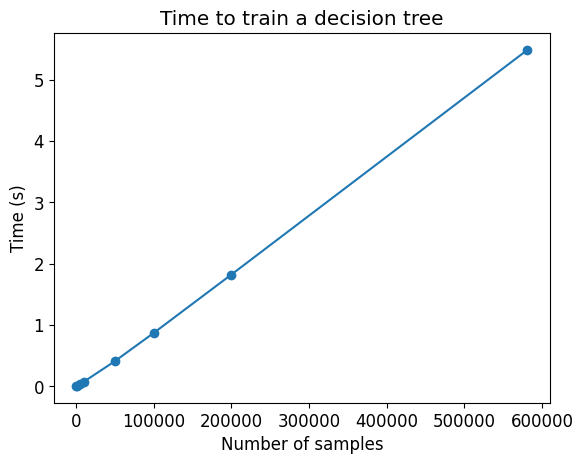

In [216]:
plt.plot(subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes], 'o-')
plt.xlabel("Number of samples")
plt.ylabel("Time (s)")
plt.title("Time to train a decision tree")

To better visualize the first data points, we can switch to a log scale on the x-axis.

Text(0.5, 1.0, 'Time to train a decision tree')

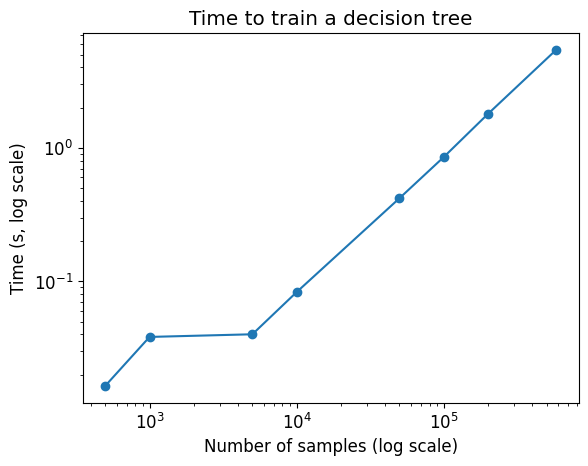

In [106]:
plt.loglog(subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes], 'o-')
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Time (s, log scale)")
plt.title("Time to train a decision tree")

#### Fitting a complexity model

It is hard to conclude on the computational complexity of the algorithm in practice from the above plot. In this section, we will check what type of computational complexity function fits our observations best. For this purpose, we'll use the [curve fitting algorithm of `scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).

In [107]:
from scipy import optimize

Let us define now 3 types of computational complexities we are willing to consider:

In [108]:
def f_linear(n, a):
    """Linear complexity"""
    return (a * n)

In [109]:
def f_loglinear(n, a):
    """Loglinear complexity"""
    return (a * n * np.log2(n))

In [110]:
def f_quadratic(n, a):
    """Quadratic complexity"""
    return (a * n**2)

Now we use `curve_fit` to fit the data to the models. What is happening under the hood is an ordinary least squares approach (minimization of the sum of squares).

In [114]:
p_opt_linear, p_cov = optimize.curve_fit(f_linear, subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes])
p_opt_loglinear, p_cov = optimize.curve_fit(f_loglinear, subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes])
p_opt_quadratic, p_cov = optimize.curve_fit(f_quadratic, subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes])

And now we plot the learned models as well as the observed runtimes.

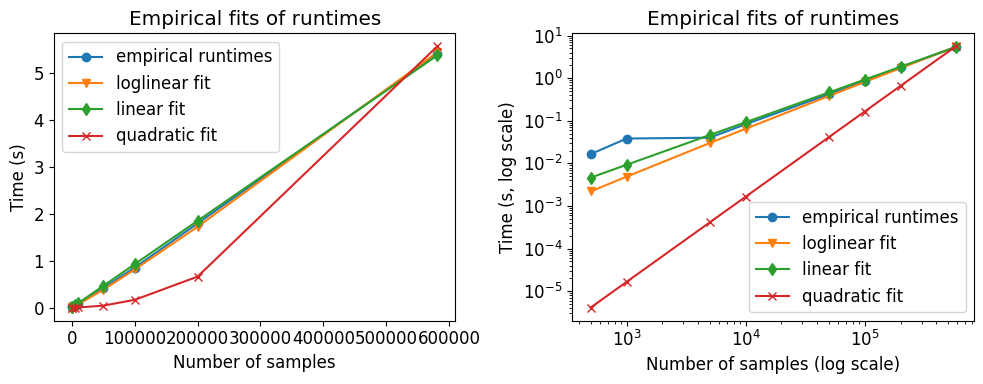

In [112]:
fig = plt.figure(figsize=(10, 4))

# Linear axes
plt.subplot(1, 2, 1) # grid 1x2 subplots, subplot 1
plt.plot(subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes], 'o-', label="empirical runtimes")
plt.plot(subsample_sizes, f_loglinear(subsample_sizes, p_opt_loglinear[0]), 'v-', label="loglinear fit")
plt.plot(subsample_sizes, f_linear(subsample_sizes, p_opt_linear[0]), 'd-', label="linear fit")
plt.plot(subsample_sizes, f_quadratic(subsample_sizes, p_opt_quadratic[0]), 'x-', label="quadratic fit")

plt.xlabel("Number of samples")
plt.ylabel("Time (s)")
plt.title("Empirical fits of runtimes")
plt.legend()

# Log axes
plt.subplot(1, 2, 2) # grid 1x2 subplots, subplot 2
plt.loglog(subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes], 'o-', label="empirical runtimes")
plt.loglog(subsample_sizes, f_loglinear(subsample_sizes, p_opt_loglinear[0]), 'v-', label="loglinear fit")
plt.loglog(subsample_sizes, f_linear(subsample_sizes, p_opt_linear[0]), 'd-', label="linear fit")
plt.loglog(subsample_sizes, f_quadratic(subsample_sizes, p_opt_quadratic[0]), 'x-', label="quadratic fit")

plt.xlabel("Number of samples (log scale)")
plt.ylabel("Time (s, log scale)")
plt.title("Empirical fits of runtimes")
plt.legend()

# Adjust spacing between plots
fig.tight_layout()

##### __Question 2__ 
Is the relationship between the time required to train a decision tree and the number of samples linear? loglinear? quadratic? Does this match your expectations?

__Answer:__ The empirical curve is best fit by the **loglinear** model O(n log n). This matches expectations: ~81% of features are binary so most splits are O(n) rather than O(n log n), so we are far from the worst-case quadratic regime.

The linear fit is also visually close because, over the relatively small range of n we tested, log n varies slowly enough to be hard to distinguish from a constant — but loglinear is the better fit on the log–log plot.

#### Size of a tree in memory

We will now use `joblib` to save estimators to disk and see how much space the models take to store.

You can read more about `joblib` [here](https://joblib.readthedocs.io/en/latest/), and about *model persistence* (ie. how to save a trained model) in scikit-learn [here](https://scikit-learn.org/stable/modules/model_persistence.html).

If `joblib` isn't installed on your system, you should be able to install it with `conda install joblib`.

In [28]:
import joblib
import os

In [164]:
tree_joblib_size = {} # key: number of subsamples, value: size of file on disk
for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dt_classifier = tree.DecisionTreeClassifier() # default parameters
    dt_classifier.fit(X_current, y_current)
    file_name = "dt_classifier_%d.joblib" % ssize
    joblib.dump(dt_classifier, file_name)
    print("Tree size: %.2e bytes" % os.path.getsize(file_name))
    print(f'Max_depth of dt is {dt_classifier.get_depth()}')
    tree_joblib_size[ssize] = os.path.getsize(file_name)


Tree size: 2.91e+04 bytes
Max_depth of dt is 20
Tree size: 5.36e+04 bytes
Max_depth of dt is 23
Tree size: 2.16e+05 bytes
Max_depth of dt is 24
Tree size: 3.95e+05 bytes
Max_depth of dt is 32
Tree size: 1.41e+06 bytes
Max_depth of dt is 34
Tree size: 2.26e+06 bytes
Max_depth of dt is 37
Tree size: 3.48e+06 bytes
Max_depth of dt is 38
Tree size: 6.61e+06 bytes
Max_depth of dt is 43


##### __Question 3__ 
Complete the code below to plot, as a function of the number of samples, the size in bytes of 1) the data set and 2) the model file.

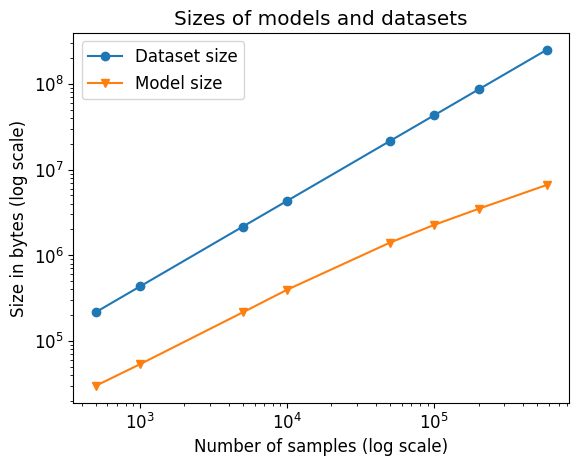

In [ ]:
dataset_sizes =[]
model_sizes =[] 

for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dataset_sizes.append(X_current.size * X_current.itemsize) 
    model_sizes.append(tree_joblib_size[ssize])
    
plt.loglog(subsample_sizes, dataset_sizes, 'o-', label='Dataset size')
plt.loglog(subsample_sizes, model_sizes, 'v-', label='Model size')

plt.xlabel("Number of samples (log scale)")
plt.ylabel("Size in bytes (log scale)")
plt.title("Sizes of models and datasets")
plt.legend()

You can check that the sizes you have computed match those given by your operating system.

For example, here's a screenshot of my file manager (for the folder in which I am running the notebook):

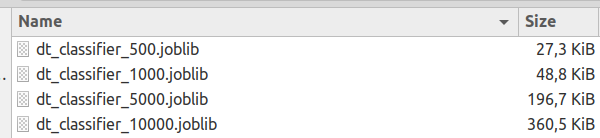

Note that my file system gives file sizes in KiB and MiB (1 KiB = $2^{10}$ B = 1024 B) and not KB and MB (1 KB = $10^3$ B = 1000 B). 

__Comment:__ 

The dataset size grows linearly with the number of samples.
This is expected since the dataset stores all feature values, so its memory usage is proportional to n×p

The model size also increases with the number of samples (for exemple : the depth is increasing with the number of sample), but much more slowly than the dataset size.
This is because a decision tree does not store the data itself, only the learned structure (splits, thresholds and node information).

You can now remove the joblib files with the following command:

In [ ]:
for ssize in subsample_sizes:
    file_name = "dt_classifier_%d.joblib" % ssize
    os.remove(file_name)

#### Limiting the depth of the tree

##### __Question 4__ 
Using the `max_depth` parameter of `DecisionTreeClassifier` to limit the depth of the learned decision tree, evaluate again:
* the runtime, as a function of the number of samples, of training a decision tree of maximum depth 4 
* the space taken in memory by such a model, as a function of the number of samples.

Compare with the previous section.

Tree size with max_depth = 4: 4.83e+03 bytes
Tree size with max_depth = 4: 4.83e+03 bytes
Tree size with max_depth = 4: 5.07e+03 bytes
Tree size with max_depth = 4: 5.07e+03 bytes
Tree size with max_depth = 4: 5.07e+03 bytes
Tree size with max_depth = 4: 5.07e+03 bytes
Tree size with max_depth = 4: 5.07e+03 bytes
Tree size with max_depth = 4: 5.07e+03 bytes


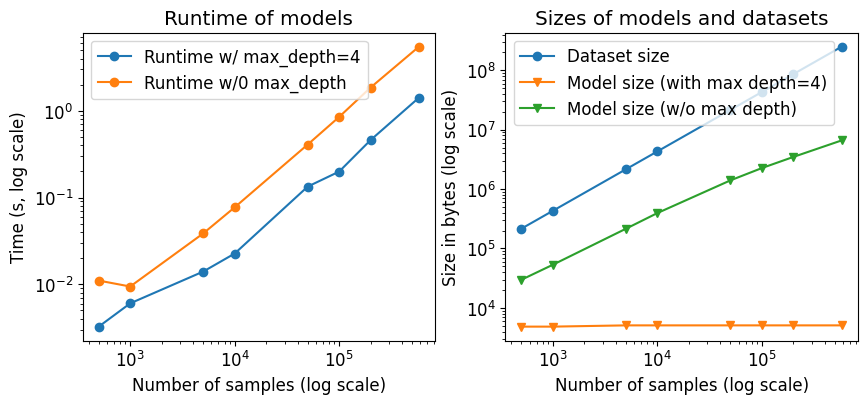

In [161]:
### 
fig = plt.figure(figsize=(10, 4))





runtimes_max_depth = {}
tree_joblib_size_max_depth = {} # key: number of subsamples, value: size of file on disk
for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dt_classifier_max_depth = tree.DecisionTreeClassifier(max_depth=4) # w/ max_depth = 4
    start_time = time.time()
    dt_classifier_max_depth.fit(X_current, y_current)
    runtimes_max_depth[ssize] = time.time() - start_time
    file_name = "dt_classifier_max_depth_%d.joblib" % ssize
    joblib.dump(dt_classifier_max_depth, file_name)
    print("Tree size with max_depth = 4: %.2e bytes" % os.path.getsize(file_name))
    tree_joblib_size_max_depth[ssize] = os.path.getsize(file_name)

plt.subplot(1,2,1)
plt.loglog(subsample_sizes, [runtimes_max_depth[ssize] for ssize in subsample_sizes], 'o-', label='Runtime w/ max_depth=4')
plt.title("Time to train a decision tree w/ max_depth = 4")
plt.loglog(subsample_sizes, [runtimes[ssize] for ssize in subsample_sizes], 'o-', label = 'Runtime w/0 max_depth')
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Time (s, log scale)")
plt.title("Runtime of models")
plt.legend()

dataset_sizes_max_depth =[]
model_sizes_max_depth =[] 


for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dataset_sizes_max_depth.append(X_current.size * X_current.itemsize) 
    model_sizes_max_depth.append(tree_joblib_size_max_depth[ssize])

### Space taken analysis

plt.subplot(1,2,2)
plt.loglog(subsample_sizes, dataset_sizes, 'o-', label='Dataset size')
plt.loglog(subsample_sizes, model_sizes_max_depth, 'v-', label='Model size (with max depth=4)')
plt.loglog(subsample_sizes, model_sizes, 'v-', label='Model size (w/o max depth)')

plt.xlabel("Number of samples (log scale)")
plt.ylabel("Size in bytes (log scale)")
plt.title("Sizes of models and datasets")
plt.legend()

__Comment:__ 

When limiting the tree depth to 4, the training runtime increases more slowly compared to the unrestricted tree.
The model size also remains almost constant as the number of samples grows.

In contrast, without depth limitation, both runtime and model size increase significantly.
This shows that tree depth is the main hyperparameters that improves scalability in terms of time and memory.

#### Impact of limiting the depth of the tree on tree performance.

##### __Question 5__ 
Using [`sklearn.model_selection.cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html?highlight=cross_val_score#sklearn.model_selection.cross_val_score), complete the code below to compute and compare the 5-fold cross-validated [balanced accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html#sklearn.metrics.balanced_accuracy_score) of all these decision trees (with/without limiting depth, for all sample sizes). 

In [165]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, make_scorer

In [224]:
cv_scores_default = {} # key: number of subsamples, value: 5-fold cv balanced accuracy
cv_scores_depth4 = {} # key: number of subsamples, value: 5-fold cv balanced accuracy

for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dt_classifier = tree.DecisionTreeClassifier() # default parameters
    cv_scores_default[ssize] = cross_val_score(dt_classifier,X_current,y_current,cv=5, scoring=make_scorer(balanced_accuracy_score)).mean()
    
    dt_classifier = tree.DecisionTreeClassifier(max_depth=4) # default parameters
    cv_scores_depth4[ssize] =cross_val_score(dt_classifier,X_current,y_current,cv=5, scoring=make_scorer(balanced_accuracy_score)).mean()

/opt/anaconda3/envs/ds/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/envs/ds/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


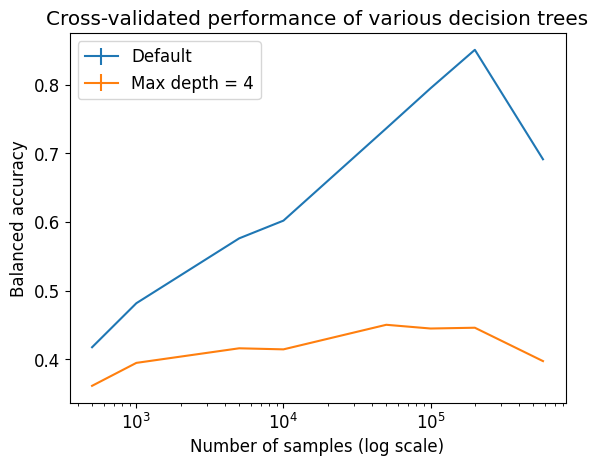

In [225]:
plt.errorbar(subsample_sizes, [np.mean(cv_scores_default[ssize]) for ssize in subsample_sizes], 
             yerr=[np.std(cv_scores_default[ssize]) for ssize in subsample_sizes], label='Default')
plt.errorbar(subsample_sizes, [np.mean(cv_scores_depth4[ssize]) for ssize in subsample_sizes],
             yerr=[np.std(cv_scores_depth4[ssize]) for ssize in subsample_sizes], label='Max depth = 4')

plt.xlabel("Number of samples (log scale)")
plt.ylabel("Balanced accuracy")
plt.title("Cross-validated performance of various decision trees")

plt.xscale("log")

plt.legend()

__Comment:__

The unrestricted decision tree achieves higher balanced accuracy as the number of samples increases, but its performance becomes unstable for very large sample sizes (which seems strange for me because if i'm not wrong adding more data should reduce variance and so increasing the balaned accuracy).

In contrast, the tree with max_depth=4 shows lower but more stable performance across all sample sizes.
This suggests that the unrestricted tree has higher capacity and may overfit the training data, while limiting the depth reduces model complexity and variance but introduces bias.

##### __Question 6__ 
* How does limiting the depth of the tree affect performance? 
* Was this expected? 
* Comment this result knowing that our ultimate goal is to train random forests.

In [ ]:
plt.figure(figsize=(7, 5))

# Default (unrestricted) tree, used as a reference
cv_scores_default = {}
for ssize in subsample_sizes:
    X_current, y_current = subsample_data[ssize]
    dt = tree.DecisionTreeClassifier()
    cv_scores_default[ssize] = cross_val_score(
        dt, X_current, y_current, cv=5,
        scoring=make_scorer(balanced_accuracy_score),
    )

# Sweep over max_depth
for maxdepth in range(1, 41, 10):
    cv_scores_depth = {}
    for ssize in subsample_sizes:
        X_current, y_current = subsample_data[ssize]
        dt = tree.DecisionTreeClassifier(max_depth=maxdepth)
        cv_scores_depth[ssize] = cross_val_score(
            dt, X_current, y_current, cv=5,
            scoring=make_scorer(balanced_accuracy_score),
        )
    plt.errorbar(
        subsample_sizes,
        [np.mean(cv_scores_depth[ssize]) for ssize in subsample_sizes],
        yerr=[np.std(cv_scores_depth[ssize]) for ssize in subsample_sizes],
        label=f'max_depth = {maxdepth}',
    )

plt.errorbar(
    subsample_sizes,
    [np.mean(cv_scores_default[ssize]) for ssize in subsample_sizes],
    yerr=[np.std(cv_scores_default[ssize]) for ssize in subsample_sizes],
    label='Default (no limit)',
)

plt.xscale("log")
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Balanced accuracy")
plt.title("Cross-validated performance vs max_depth")
plt.legend()

Limiting the depth of the tree reduces its performance (lower balanced accuracy). The shallow tree cannot capture complex patterns in the data, which leads to higher bias.
It was predictable because  smaller max_depth reduces the model capacity to fit well the dataset. This limits overfitting but can also add to much bias for the bigger datasets, which results in lower predictive performance.

However, in random forests, individual trees do not need to be perfect. The ensemble reduces variance and improves generalization, so even weak trees can contribute to strong overall performance and thus offset the overall accuracy.

*(See the comment above — answer to Q6.)*

### 2.2 Computational complexity of a decision tree (with respect to the number of features)

Here we'll work with the data set that has 10,000 samples (to avoid longer runtimes on the full data set) and change the number of features. If 10,000 samples takes too long to process on your data set, use a smaller dataset.

#### Creating subsets of varying numbers of features

Here we will merely add random binary features to the data. They will not be useful, but the algorithm will still have to explore them to know that.

In [228]:
n_subsamples = int(1e4)
X_current, y_current = subsample_data[n_subsamples]


Let us now define a list of feature numbers.

In [207]:
feature_numbers = [n_features, 100, 500, 1000, 1500] # You can change the values here 
feature_numbers = np.array(feature_numbers)

Now we create the copies of the dataset "augmented" with bogus binary features.

In [ ]:
augmented_data = {} #key: number of features, value: X_augmented
augmented_data[n_features] = X_current
for fnum in feature_numbers[1:]:
    # Create an array of random binary features
    X_aug = np.random.randint(2, size=(n_subsamples, fnum))
    # Fill the first 54 columns with the true data
    X_aug[:, :n_features] = X_current        
    augmented_data[fnum] = X_aug

#### Size of each data set in memory

##### __Question 7__ 
Compute the sizes of each data set in bytes.

Dataset with 54 features takes 4.32e+06 bytes of memory
Dataset with 100 features takes 8.00e+06 bytes of memory
Dataset with 500 features takes 4.00e+07 bytes of memory
Dataset with 1000 features takes 8.00e+07 bytes of memory
Dataset with 1500 features takes 1.20e+08 bytes of memory


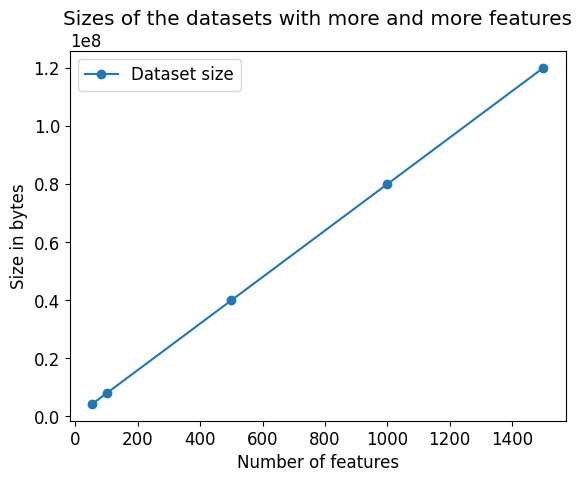

In [219]:
dataset_sizes =[]
for nb_features in feature_numbers:
    X_current = augmented_data[nb_features]
    dataset_sizes.append(X_current.size * X_current.itemsize) 
    print(f"Dataset with {nb_features} features takes {(X_current.size * X_current.itemsize):.2e} bytes of memory")



    
plt.plot(feature_numbers, dataset_sizes, 'o-', label='Dataset size')

plt.xlabel("Number of features")
plt.ylabel("Size in bytes")
plt.title("Sizes of the datasets with more and more features")
plt.legend()


__Comment:__ 
The graph clearly shows that memory usage increases linearly with the number of features.
This is expected because the dataset size is proportional to the total number of stored values (samples × features).

#### Tree complexity as a function of the number of features

##### __Question 8__ 
Compute and plot
* the runtime, as a function of the number of features, of training a decision tree with no limit on the depth
* the space taken in memory by  a decision tree with no limit on the depth, as a function of the number of features
* the runtime, as a function of the number of features, of training a decision tree of maximum depth 4
* the space taken in memory by a decision tree of maximum depth 4, as a function of the number of features.

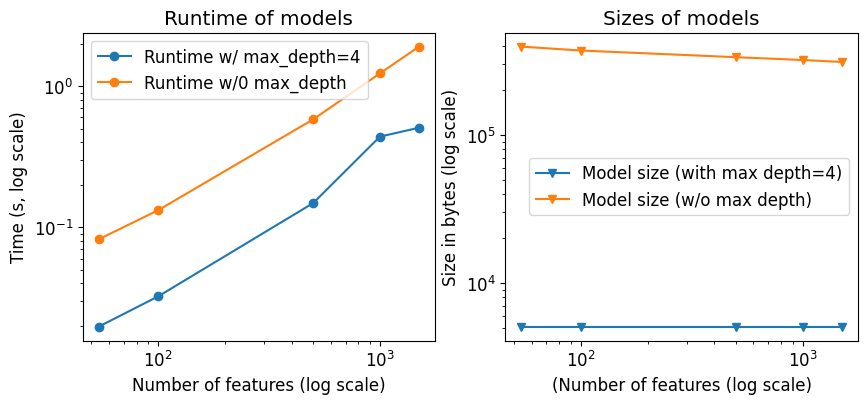

In [232]:
### 
fig = plt.figure(figsize=(10, 4))
model_sizes_max_depth =[] 
model_sizes = []

runtimes = {}
runtimes_max_depth = {}
tree_joblib_size_max_depth = {}
tree_joblib_size = {}
 # key: number of subsamples, value: size of file on disk
for nb_features in feature_numbers:
    X_current = augmented_data[nb_features]

    # without max depth

    dt_classifier = tree.DecisionTreeClassifier() # w/o max_depth 
    start_time = time.time()
    dt_classifier.fit(X_current, y_current) # y_current remain the same
    runtimes[nb_features] = time.time() - start_time
    file_name = "dt_classifier_%d.joblib" % nb_features

    joblib.dump(dt_classifier, file_name)
    tree_joblib_size[nb_features] = os.path.getsize(file_name)
    model_sizes.append(tree_joblib_size[nb_features])

    # with max depth

    dt_classifier_max_depth = tree.DecisionTreeClassifier(max_depth=4) # w/ max_depth = 4
    start_time = time.time()
    dt_classifier_max_depth.fit(X_current, y_current) # y_current remain the same)
    runtimes_max_depth[nb_features] = time.time() - start_time
    file_name = "dt_classifier_max_depth_%d.joblib" % nb_features

    joblib.dump(dt_classifier_max_depth, file_name)
    tree_joblib_size_max_depth[nb_features] = os.path.getsize(file_name)
    model_sizes_max_depth.append(tree_joblib_size_max_depth[nb_features])


plt.subplot(1,2,1)
plt.loglog(feature_numbers, [runtimes_max_depth[nb_features] for nb_features in feature_numbers], 'o-', label='Runtime w/ max_depth=4')
plt.loglog(feature_numbers, [runtimes[nb_features] for nb_features in feature_numbers], 'o-', label = 'Runtime w/0 max_depth')
plt.xlabel("Number of features (log scale)")
plt.ylabel("Time (s, log scale)")
plt.title("Runtime of models")
plt.legend()

### Space taken analysis

plt.subplot(1,2,2)
plt.loglog(feature_numbers, model_sizes_max_depth, 'v-', label='Model size (with max depth=4)')
plt.loglog(feature_numbers, model_sizes, 'v-', label='Model size (w/o max depth)')

plt.xlabel("(Number of features (log scale)")
plt.ylabel("Size in bytes (log scale)")
plt.title("Sizes of models")
plt.legend()

__Comment:__

As the number of features increases, the training time increases for both models.
The unrestricted tree is consistently slower than the tree with max_depth=4.

Regarding memory usage, the model size without depth limitation is significantly larger, while the size of the depth-limited tree remains almost constant as the number of features grows.

##### __Question 9__ 
* What is the relationship (logistic, linear, loglinear, quadratic, etc.) between the number of features and the runtime? 
* Does it match your expectations?

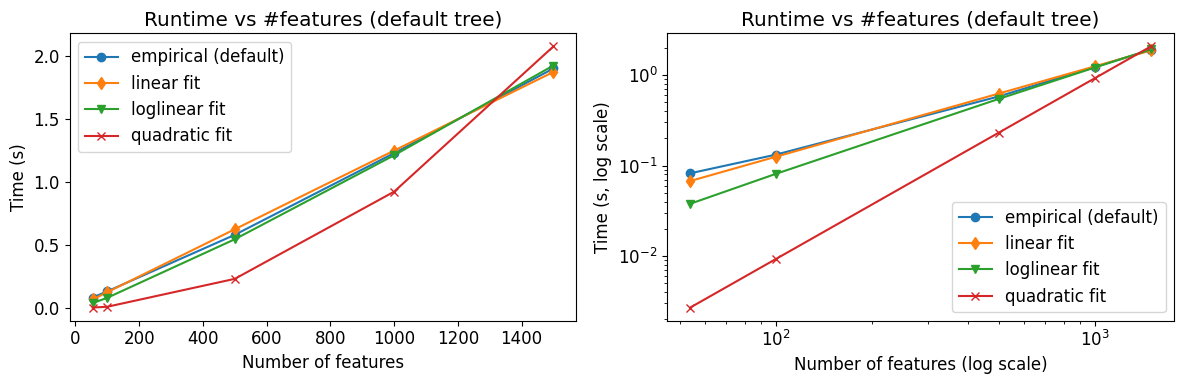

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

p_vals = np.array(feature_numbers, dtype=float)

t_default = np.array([runtimes[p] for p in feature_numbers], dtype=float)
t_depth4  = np.array([runtimes_max_depth[p] for p in feature_numbers], dtype=float)

def g_linear(p, a):
    return a * p

def g_loglinear(p, a):
    return a * p * np.log2(p)

def g_quadratic(p, a):
    return a * p**2

# Fit each model w/o max depth 
popt_lin_def, _ = optimize.curve_fit(g_linear,    p_vals, t_default, maxfev=10000)
popt_log_def, _ = optimize.curve_fit(g_loglinear, p_vals, t_default, maxfev=10000)
popt_quad_def,_ = optimize.curve_fit(g_quadratic, p_vals, t_default, maxfev=10000)

# Fit each model w/ max depth
popt_lin_d4, _ = optimize.curve_fit(g_linear,    p_vals, t_depth4, maxfev=10000)
popt_log_d4, _ = optimize.curve_fit(g_loglinear, p_vals, t_depth4, maxfev=10000)
popt_quad_d4,_ = optimize.curve_fit(g_quadratic, p_vals, t_depth4, maxfev=10000)

fig = plt.figure(figsize=(12, 4))

# --------- Default tree ----------
plt.subplot(1, 2, 1)
plt.plot(p_vals, t_default, 'o-', label="empirical (default)")
plt.plot(p_vals, g_linear(p_vals, popt_lin_def[0]), 'd-', label="linear fit")
plt.plot(p_vals, g_loglinear(p_vals, popt_log_def[0]), 'v-', label="loglinear fit")
plt.plot(p_vals, g_quadratic(p_vals, popt_quad_def[0]), 'x-', label="quadratic fit")
plt.xlabel("Number of features")
plt.ylabel("Time (s)")
plt.title("Runtime vs #features (default tree)")
plt.legend()

# --------- Log-log (often easiest to see scaling) ----------
plt.subplot(1, 2, 2)
plt.loglog(p_vals, t_default, 'o-', label="empirical (default)")
plt.loglog(p_vals, g_linear(p_vals, popt_lin_def[0]), 'd-', label="linear fit")
plt.loglog(p_vals, g_loglinear(p_vals, popt_log_def[0]), 'v-', label="loglinear fit")
plt.loglog(p_vals, g_quadratic(p_vals, popt_quad_def[0]), 'x-', label="quadratic fit")
plt.xlabel("Number of features (log scale)")
plt.ylabel("Time (s, log scale)")
plt.title("Runtime vs #features (default tree)")
plt.legend()

fig.tight_layout()

__Comment:__

The runtime grows approximately linearly with the number of features. This matches expectations since more features imply more candidate splits to evaluate, leading to a roughly linear increase in computational cost (O(p* n**2)).

## 3. Random forests

### 3.1 Complexity of training a random forest

Training a random forest is done by constructing `n_trees` decision trees, each trained on a data set constructing by
* subsampling the observations; typically, this is done with bootstrap sampling, where $n$ observations are sampled *with replacement* (i.e. some will be sampled several times and others never, resulting in approximately selecting 2/3 of the samples);
* subsampling the features; typically, this is done by randomly sampling $p$ features.

##### __Question 10__ 
* What do you expect the time complexity of training __one__ of the decision trees of a random forest?
* How much time do you expect training a random forest of 100 trees on the full data set will take if you're not limiting tree depth? If you're limiting tree depth?
* How much space do you expect that random forest model to take in memory if you're not limiting tree depth? If you're limiting tree depth?

__Answer:__

A single RF tree is trained on about 0.63 n samples (bootstrap) and, at each split, it tests only  p_selected  features <p instead of all p. So its training complexity is roughly: 
Without depth limit (balanced case):     O ( n*p_selected*log(n) ) O ( n*p_selected*log(n) ) 
With max_depth = d fixed:     O ( n*p_selected )

And training time should scales linearly with the number of trees, so it will take n_estimators times more longer than with 1 estimator for a RF
Without depth limit:     O ( 100*n*p_selected* log ⁡ n ) 
With depth limit:     O ( 100*n *p_selected )

the 'log(n)' term disapears in the complexity term for a fixed depth limit because the depth number is now fixed.

About memory, it grows linearly with the number of trees as we saw previously.
Without depth limitation:
Each tree can become large, so total memory is roughly
100 × the size of one deep tree, which can be significant.
With depth limitation:
Each tree has a bounded number of nodes, so its size remains controlled.
Total memory is therefore
100 × bounded tree size, making the model much more memory-efficient.


##### __Question 11__ 
* Set up an experiment to verify this complexity using the [`sklearn.ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier) class. Use at least 100 trees in your random forest. 
Make sure to use the training times you have observed before to decide on the numbers of samples to use. Do not limit tree depth. Do the numbers match your expectations?
* How much space do your trained random forests take in memory? Does this match your expectations?

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [247]:
n_trees = 100

rf_runtimes = {}       
rf_joblib_size = {}     

for ssize in subsample_sizes: 
    X_current, y_current = subsample_data[ssize]

    rf = RandomForestClassifier(
        n_estimators=n_trees,         
        random_state=0
    )

    start = time.time()
    rf.fit(X_current, y_current)
    rf_runtimes[ssize] = time.time() - start

    file_name = f"rf_{n_trees}_trees_{ssize}.joblib"
    joblib.dump(rf, file_name)
    rf_joblib_size[ssize] = os.path.getsize(file_name)

    print(f"n={ssize:>7} time={rf_runtimes[ssize]:.3f}s  size={rf_joblib_size[ssize]:.2e} bytes")

n=    500 time=0.128s  size=3.02e+06 bytes
n=   1000 time=0.190s  size=5.79e+06 bytes
n=   5000 time=0.892s  size=2.52e+07 bytes
n=  10000 time=1.842s  size=4.64e+07 bytes
n=  50000 time=8.713s  size=1.86e+08 bytes
n=  75000 time=13.183s  size=2.60e+08 bytes
n= 100000 time=18.223s  size=3.29e+08 bytes
n= 581012 time=88.953s  size=1.26e+09 bytes


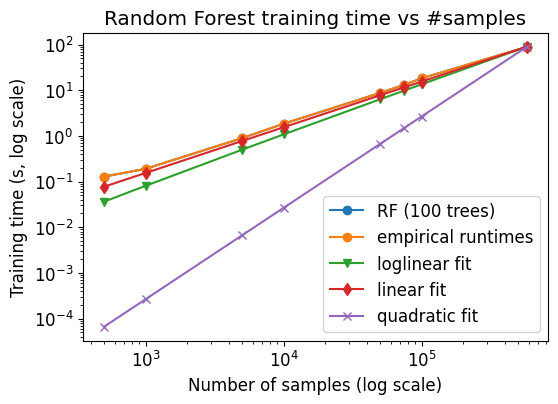

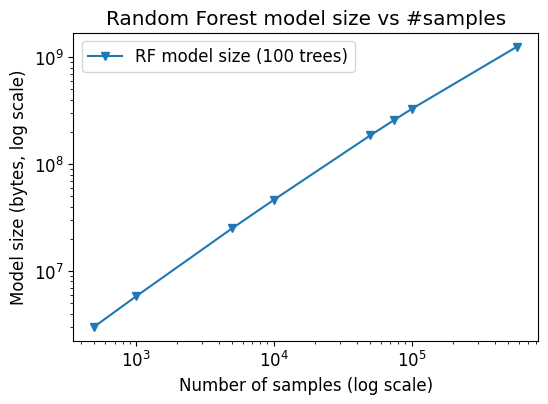

In [253]:
p_opt_linear, p_cov = optimize.curve_fit(f_linear, subsample_sizes, [rf_runtimes[ssize] for ssize in subsample_sizes])
p_opt_loglinear, p_cov = optimize.curve_fit(f_loglinear, subsample_sizes, [rf_runtimes[ssize] for ssize in subsample_sizes])
p_opt_quadratic, p_cov = optimize.curve_fit(f_quadratic, subsample_sizes, [rf_runtimes[ssize] for ssize in subsample_sizes])


# Linear axes

plt.figure(figsize=(6,4))
plt.loglog(subsample_sizes, [rf_runtimes[s] for s in subsample_sizes], 'o-', label=f'RF ({n_trees} trees)')
plt.plot(subsample_sizes, [rf_runtimes[ssize] for ssize in subsample_sizes], 'o-', label="empirical runtimes")
plt.plot(subsample_sizes, f_loglinear(subsample_sizes, p_opt_loglinear[0]), 'v-', label="loglinear fit")
plt.plot(subsample_sizes, f_linear(subsample_sizes, p_opt_linear[0]), 'd-', label="linear fit")
plt.plot(subsample_sizes, f_quadratic(subsample_sizes, p_opt_quadratic[0]), 'x-', label="quadratic fit")
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Training time (s, log scale)")
plt.title("Random Forest training time vs #samples")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.loglog(subsample_sizes, [rf_joblib_size[s] for s in subsample_sizes], 'v-', label=f'RF model size ({n_trees} trees)')
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Model size (bytes, log scale)")
plt.title("Random Forest model size vs #samples")
plt.legend()
plt.show()



##### Dataset size vs RF model size
Plot, as a function of the number of samples, the size in bytes of 1) the data set and 2) the trained random forest.

In [ ]:
rf_dataset_sizes = []
rf_model_sizes = []
for ssize in subsample_sizes:
    X_current, _ = subsample_data[ssize]
    rf_dataset_sizes.append(X_current.size * X_current.itemsize)
    rf_model_sizes.append(rf_joblib_size[ssize])

plt.figure(figsize=(6, 4))
plt.loglog(subsample_sizes, rf_dataset_sizes, 'o-', label='Dataset size')
plt.loglog(subsample_sizes, rf_model_sizes,  'v-', label=f'RF model size ({n_trees} trees)')
plt.xlabel("Number of samples (log scale)")
plt.ylabel("Size in bytes (log scale)")
plt.title("RF model size vs dataset size")
plt.legend()
plt.show()

# clean up the joblib files written during the RF training loop
for ssize in subsample_sizes:
    file_name = f"rf_{n_trees}_trees_{ssize}.joblib"
    if os.path.exists(file_name):
        os.remove(file_name)

__Comment:__ 

We trained a RandomForestClassifier with 100 trees on increasing sample sizes and measured training time and model size.

Training time grows approximately loglinearly (≈ n log n), which matches our expectations since each tree has this complexity and the forest multiplies it by 100.
Model size increases strongly with the number of samples because larger datasets produce deeper trees, and the total size scales with both the number of nodes and the 100 trees.


### 3.2 Prediction latency

Doing predictions in bulk (many samples at the same time) rather than one sample at a time is more efficient. This is due to several reasons, that include CPU caching and [branch prediction](https://en.wikipedia.org/wiki/Branch_predictor). For many models, this can also be due to the efficiency of linear algebra libraries.

Here is an example for one random forest, trained on 5,000 samples, with 100 trees:

In [ ]:
ssize = 5000
X_current, y_current = subsample_data[ssize]
rf_classifier = RandomForestClassifier(max_depth=4)

# Training
rf_classifier.fit(X_current, y_current)

# Predicting on 1 sample
start_time = time.time()
rf_classifier.predict(X_current[:1, :])
mytime = time.time() - start_time
print("Time to predict on one sample: %.3f s" % (mytime))
print("Time to predict on one sample (x %d): %.2f s" % (ssize, (mytime * ssize)))

# Predicting on 5000 samples
start_time = time.time()
rf_classifier.predict(X_current)
print("Time to predict on %d samples: %.2f s" % (ssize, (time.time() - start_time)))

##### __Question 12__ 
For several values of n, compare the time it takes to predict on n samples to n times the time it takes to predict on 1 sample. Produce a plot.

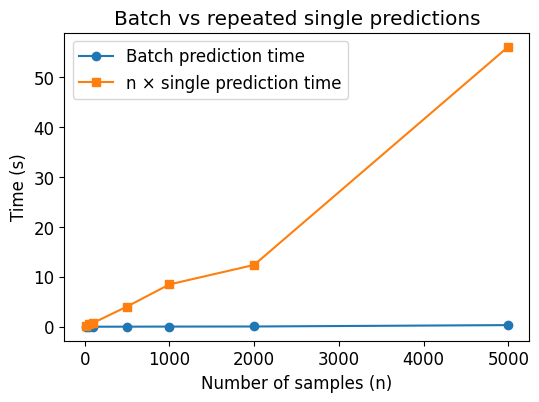

In [ ]:
# Train one RF model (once)
ssize = 5000
X_current, y_current = subsample_data[ssize]

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_current, y_current)

n_values = np.array([10, 50, 100, 500, 1000, 2000, 5000])

batch_times = []
scaled_single_times = []

for n in n_values:
    
    # Time for 1 sample
    start = time.time()
    for i in range(n):
        rf.predict(X_current[:1])
    t_single = time.time() - start
    
    # Time for n samples in batch
    start = time.time()
    rf.predict(X_current[:n])
    t_batch = time.time() - start
    
    batch_times.append(t_batch)
    scaled_single_times.append(t_single)

plt.figure(figsize=(6,4))
plt.plot(n_values, batch_times, 'o-', label='Batch prediction time')
plt.plot(n_values, scaled_single_times, 's-', label='n × single prediction time')

plt.xlabel("Number of samples (n)")
plt.ylabel("Time (s)")
plt.title("Batch vs repeated single predictions")
plt.legend()
plt.show()


__Comment:__

We can confirm that doing bulk prediction is much more efficient than doing n predicition one by one. The preidction time is more or less quadratic with n for the second case ! 

### 3.3 Parallelization

Random forests are embarassingly parallel, meaning that very little effort is required to parallelize them: all of the decision trees that compose it can be trained and applied independently from each other. If your machine has several computing cores, each of them can be used to compute some trees in parallel. `scikit-learn` facilitates this with the `n_jobs` parameter of the `RandomForestClassifier` class.

##### __Question 13__ 
* Compare the runtime of training a random forest using a single core (`n_jobs=None`, default), using two cores (`n_jobs=2`), and using as many cores as possible (`n_jobs=-1`). You are free to choose wether you're limiting depth or not, how many samples you use, and so on.
* Do the results match your expectations?

In [ ]:
ssize = 50000
X_current, y_current = subsample_data[ssize]

n_jobs_values = [1, 2, 3, 4, 5, 6, 7, 8]  # 8 cores on this machine

training_times = []
for n_jobs in n_jobs_values:
    rf = RandomForestClassifier(
        n_estimators=100,
        n_jobs=n_jobs,
        random_state=0,
    )
    start_time = time.time()
    rf.fit(X_current, y_current)
    elapsed = time.time() - start_time
    training_times.append(elapsed)
    print(f"n_jobs={n_jobs} training time: {elapsed:.2f} s")

plt.figure(figsize=(6, 4))
plt.plot(n_jobs_values, training_times, 'o-')
plt.xlabel("Number of jobs (cores used)")
plt.ylabel("Training time (s)")
plt.title("Random Forest training time vs parallelization")
plt.xticks(n_jobs_values)
plt.grid(True)
plt.show()

__Comment:__ Going from 1 to 2 cores roughly halves the training time, and adding more cores keeps reducing it but with diminishing returns (the speed-up is sublinear). This is consistent with Amdahl's law: a small portion of the work (data preparation, bootstrap sampling, joining results) is sequential and cannot be parallelized, so beyond a certain point adding cores no longer helps.

## 4. (Optional) Incremental PCA

Another technique to reduce computation overheads is `incremental learning`, or `mini-batch learning`, or `online learning`. The idea here is to process only a small number of samples at once (one such set of samples is called a batch). This is typically how neural networks are trained, with gradient updates computed sample per sample or mini-batch per mini-batch.
 
The technique can also be applied to other examples, such as Principal Component Analysis. The principle is described in [Weng et al. (2003), *Candid Covariance-Free IncrementalPrincipal Component Analysis*, TPAMI](http://www.cse.msu.edu/~weng/research/CCIPCApami.pdf). Here we will focus on observing its effects on efficiency.

Note that there's a variant of random forests, called Mondrian forests, that allows for online learning, but it is not yet mainstream and it is not implemented in scikit-learn. See [Lakshminarayanan et al. (20140, *Mondrian Forests: Efficient Online Random Forests*, NeurIPS](https://papers.nips.cc/paper/2014/hash/d1dc3a8270a6f9394f88847d7f0050cf-Abstract.html) for classification and [Lakshminarayanan et al. (2016) *Mondrian Forests for Large-Scale Regression when Uncertainty Matters*, AISTATS](http://proceedings.mlr.press/v51/lakshminarayanan16.html) for regression.

#### Memory profiling

Profiling memory usage in a Jupyter notebook can be done thanks to the magic `%memit`.

In order to use it, you may need to install [`memory_profiler`](https://pypi.org/project/memory-profiler/) with `conda install memory_profiler`.

Here we'll just test this is working:

In [ ]:
%load_ext memory_profiler

In [ ]:
%memit print("Hello World")

Notice that the code was run several times to obtain the estimate.

`peak memory` is the total memory usage of your system, including that consumed by running the profiled command. Although this is informative, and can tell you how close you are of running out of memory to run your code, what we're interested in here is `increment`, which tells you by how much global memory usage increased with respect to the memory usage just before running the profiled command.

#### PCA vs IPCA

The following code can be used to compare classical PCA and incremental PCA with batch size 10 on one of our data sets (with 1500 features). 

In [ ]:
from sklearn import decomposition

In [ ]:
fnum = 1000
n_subsamples = int(1e4)
X_current, y_current = subsample_data[n_subsamples]
X_current = augmented_data[fnum]

n_components = 2 # number of principal components to compute

In [ ]:
# Classical PCA
pca = decomposition.PCA(n_components=n_components)

# Timing the run
start_time = time.time()
X_pca = pca.fit_transform(X_current)
mytime = time.time() - start_time
print("Time to run classical PCA: %.3f s" % (mytime))

# Evaluating memory usage
%memit X_pca = pca.fit_transform(X_current)

In [ ]:
# Incremental PCA
ipca = decomposition.IncrementalPCA(n_components=n_components, batch_size=10)

# Timing the run
start_time = time.time()
X_ipca = ipca.fit_transform(X_current)
mytime = time.time() - start_time
print("Time to run incremental PCA: %.3f s" % (mytime))

# Evaluating memory usage
%memit X_ipca = ipca.fit_transform(X_current)

__Questions:__
* Compare the two approaches in terms of runtime and memory consumption.
* Do you expect the number of samples or the number of features to have the largest impact on memory consumption for PCA? On runtime?

__Instructions:__ 
* Evaluate the impact of the batch size on both the runtime and the memory consumption of iterative PCA. 
* Optionally, evaluate how runtime and memory consumption vary as a function of number of features and/or number of samples.

In [ ]:
# Compare classical PCA against Incremental PCA at several batch sizes.
fnum = 1000
n_subsamples = int(1e4)
X_current = augmented_data[fnum]

n_components = 2

# Reference: classical PCA
start = time.time()
decomposition.PCA(n_components=n_components).fit_transform(X_current)
pca_time = time.time() - start
print(f"Classical PCA: {pca_time:.3f} s")

# Sweep over batch sizes for Incremental PCA
batch_sizes = [10, 50, 100, 500, 1000, 5000]
ipca_times = []
for bs in batch_sizes:
    start = time.time()
    decomposition.IncrementalPCA(n_components=n_components, batch_size=bs).fit_transform(X_current)
    ipca_times.append(time.time() - start)
    print(f"Incremental PCA (batch={bs:>5}): {ipca_times[-1]:.3f} s")

plt.figure(figsize=(6, 4))
plt.plot(batch_sizes, ipca_times, 'o-', label='Incremental PCA')
plt.axhline(pca_time, color='r', linestyle='--', label='Classical PCA')
plt.xscale("log")
plt.xlabel("Batch size (log scale)")
plt.ylabel("Runtime (s)")
plt.title("Incremental PCA runtime vs batch size")
plt.legend()
plt.show()

__Answer:__

* **Runtime.** Classical PCA is faster than Incremental PCA on this dataset (one SVD on the full matrix beats many smaller SVDs). The runtime of Incremental PCA decreases as the batch size grows — small batches mean many more partial-fit calls and more Python-level overhead — and converges towards (but stays above) classical PCA.

* **Memory.** Classical PCA needs to hold the full data matrix in memory (and a few full-size intermediate matrices). Incremental PCA only needs a chunk of `batch_size` rows at a time, so its peak memory is dominated by `batch_size × n_features` plus the persistent `n_components × n_features` components matrix — much smaller when `n_samples` is large.

* **What drives memory in PCA?** The number of **samples** is the dominant driver of memory for classical PCA on tall matrices (n ≫ p), because the data matrix and the centered copy scale as n × p. The number of features mainly drives the cost of the SVD itself (roughly O(min(n²p, np²))), so features dominate **runtime** while samples dominate **memory**. Incremental PCA breaks the n-dependence of memory by streaming the rows.

The following code allows you to plot the data projected onto the 2 PCs computed by PCA, on the one hand, and iterative PCA, on the other hand. 

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# Custom color map with 7 discrete values
base_cmap = plt.cm.get_cmap('tab10')
color_list = base_cmap(np.linspace(0, 1, 7))
custom_cmap = matplotlib.colors.ListedColormap(color_list)

# Projection on the PCs computed by classical PCA
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_current, marker='o')
axs[0].set_aspect(1.)
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")
axs[0].set_title("Classical PCA")

# Projection on the PCs computed by incremental PCA
ppp = axs[1].scatter(X_ipca[:, 0], X_ipca[:, 1], c=y_current, marker='v')
axs[1].set_aspect(1.)
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")
axs[1].set_title("Incremental PCA")

# Adjust space between plots
fig.subplots_adjust(wspace=.4)

# Colorbar
fig.colorbar(ppp, ax=axs, label="class")

__Question__ How much did using incremental PCA affect the output of the algorithm?

__Answer:__

The two projections look essentially the same up to a sign flip on one of the principal components (PCA's components are only defined up to a sign). Class clusters and their relative geometry are preserved, so for downstream tasks like visualisation or classification the choice between PCA and Incremental PCA has effectively no impact here.

Tiny numerical differences exist because Incremental PCA is built from a sequence of partial SVDs rather than one global SVD, but with a reasonable batch size they remain well below the noise level of the projection.